In [9]:
import importlib
import inventory.inventory_models
importlib.reload(inventory.inventory_models)
from inventory.inventory_models import InventoryParams
import inventory.inventory_analysis
importlib.reload(inventory.inventory_analysis)
from inventory.inventory_analysis import InventorySimulation
import warnings
warnings.filterwarnings('ignore' , category = DeprecationWarning)
import matplotlib.pyplot as plt
import math

In [10]:
# Total Demand (yearly)
D = 2000
# Total Simulation Time (days)
T_total = 365
# Demande per Day
D_day = D / T_total
# Replenishment Period (days)
T = 10
# Purchase cost of the product (Euros/unit)
c = 50
# Cost of placing an order (/order)
c_t = 500
# Holding Cost (% unit cost per year)
h = 0.25
c_e = h * c
# Selling Price (Euros/unit)
p = 75
# Cost of shortage (Euros/unit)
c_s = 12

#### Scenario 1,2 and 3
- No Lead Time
- Simple Ordering Policy

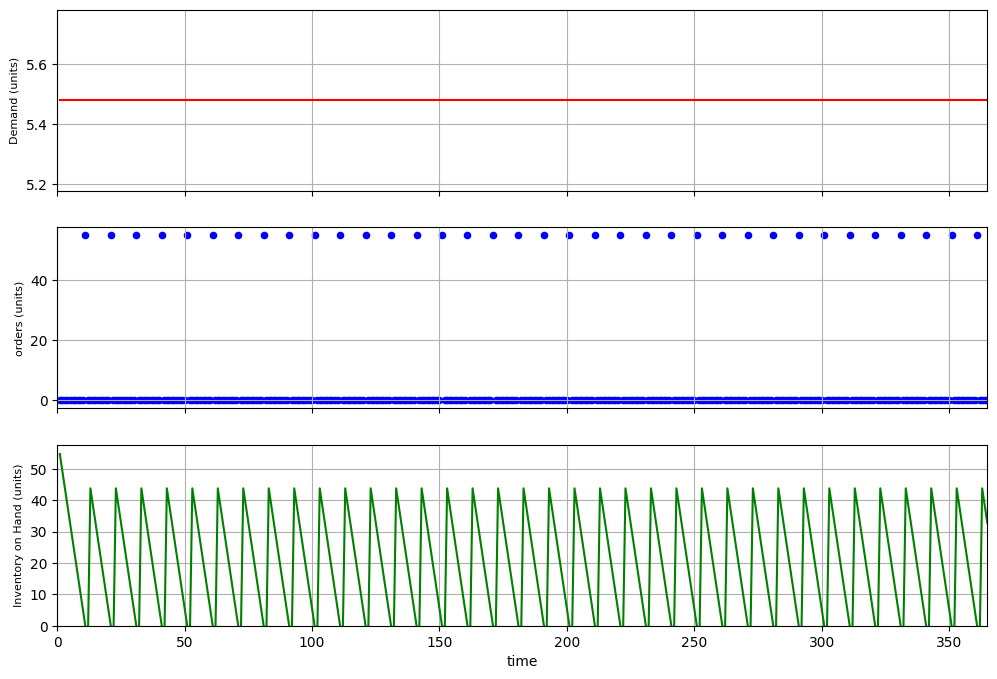

In [11]:
# Total Demand (yearly)
D1 = 2000
#  Lead Time ( days )
LD1 = 2
# Ordering Quanityt ( units )
Q1 = D_day * T
# Initial Inventory on Hand ( units )
initial_ioh1 = Q1

# Import Paramters
params1 = InventoryParams(
    D = D1,
    T_total = T_total,
    LD=LD1,
    T=T,
    Q=Q1,
    initial_ioh = initial_ioh1
)

# Create Simulation
simulate_1 = InventorySimulation(params1)
sim1 = simulate_1.simulation_1()
sim1

# Create plot to visualise inventory levels over time
fig , axes = plt.subplots(3, 1, figsize = (12,8) , sharex = True)
#All subplots share the same x-axis

# Plot the demandQ = D_day * (T + (LD-1))`
sim1.plot(x= 'time' , y = 'demand' , ax= axes[0], color = 'red', legend= False, grid= True)
axes[0].set_ylabel('Demand (units)', fontsize = 8)

# Orders
sim1.plot.scatter(x= 'time' , y = 'order' , ax= axes[1], color = 'blue', legend= False, grid= True)
axes[1].set_ylabel('orders (units)', fontsize = 8)

# Inventory on Hand
sim1.plot(x= 'time' , y = 'ioh' , ax= axes[2], color = 'green', legend= False, grid= True)
axes[2].set_ylabel('Inventory on Hand (units)', fontsize = 8)

# Format x axis
axes[2].set_xlim(0,T_total)
axes[2].set_ylim(0)


plt.show()

#### Scenario 4
- Leadtime
- Ordering function compensating leatime

(0.0, 57.53424657534248)

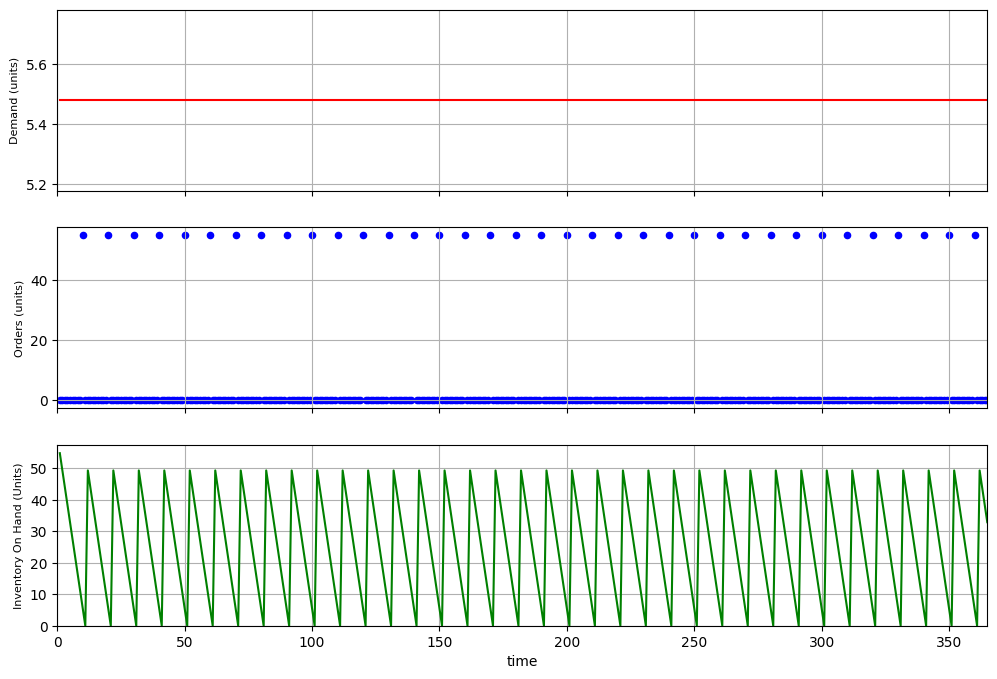

In [12]:
# Total Demand (yearly)
D4 = 2000
# Lead Time (days)
LD4 = 2
# Ordering Quantity (units)
Q4 = D_day * (T)
# Initial Inventory on Hand (units)
initial_ioh4=Q4

# Import Parameters
params4 = InventoryParams(
    D=D4,
    T_total=T_total,
    LD=LD4,
    T=T,
    Q=Q4,
    initial_ioh=initial_ioh4
)

# Create simulation
simulate_4 = InventorySimulation(params4)
sim4 = simulate_4.simulation_2()

# Create plot to visualize inventory levels over time
fig, axes = plt.subplots(3, 1, figsize= (12,8), sharex=True)

# Plot the demand
sim4.plot(x='time', y = 'demand', ax = axes[0], color='red', legend=False, grid = True)
axes[0].set_ylabel('Demand (units)', fontsize = 8)

# Orders
sim4.plot.scatter(x='time', y = 'order', ax = axes[1], color='blue', legend=False, grid = True)
axes[1].set_ylabel('Orders (units)', fontsize = 8)

# Inventory on Hand
sim4.plot(x='time', y = 'ioh', ax = axes[2], color='green', legend=False, grid = True)
axes[2].set_ylabel('Inventory On Hand (Units)', fontsize = 8)

# Format x axis
axes[2].set_xlim(0, T_total)
axes[2].set_ylim(0)

#### Scenario 5: Economic Order Quantity

EOQ = (:,) units/order
Replenishment Cycle Time = 73.00 days


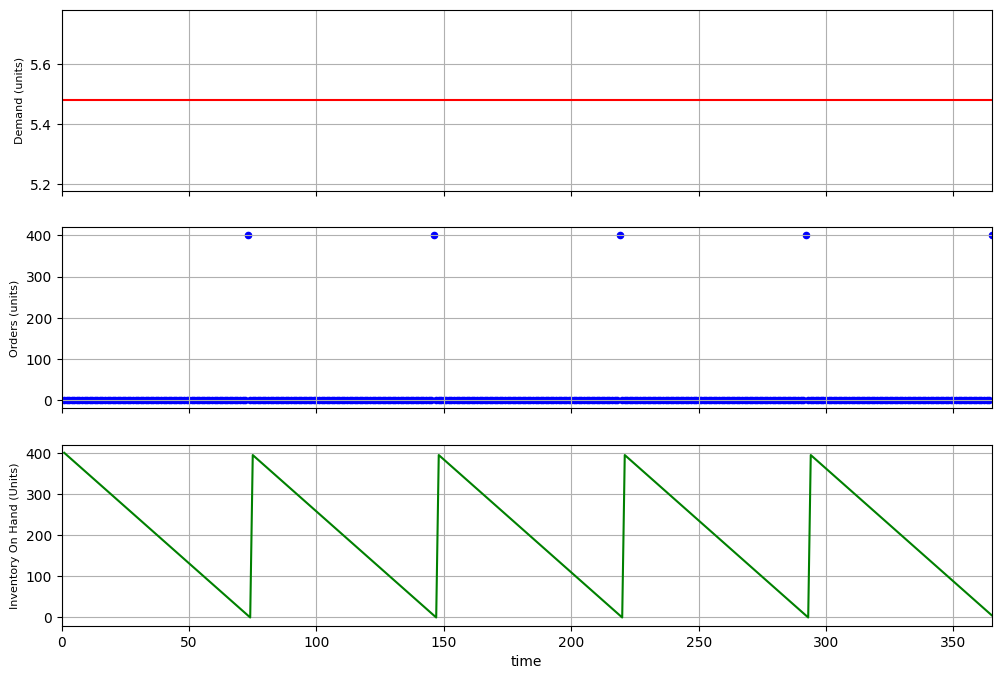

In [13]:
# Purchase cost of the product (Euros/unit)
c5 = 50
# Cost of placing an order (/order)
c_t5 = 500
# Holding Cost (% unit cost per year)
h5 = 0.25
c_e5 = h * c
# Selling Price (Euros/unit)
p5 = 75
# Cost of shortage (Euros/unit)
c_s5 = 12
# Lead Time (day)
LD5 = 2
# EOQ
Q5 = math.sqrt((2*c_t5*D1)/c_e5)
print('EOQ = (:,) units/order'.format(Q1))
# Replacement Cycle (days)
T5 = (Q5/D)* T_total
print(f"Replenishment Cycle Time = {T5:.2f} days")
# Initial Inventory on Hand (units)

initial_ioh5 = Q5
params = InventoryParams(
    D=D,
    T_total=T_total,
    LD =LD5,
    T = T5,
    Q=Q5,
    initial_ioh=initial_ioh5
)
simulate_5 = InventorySimulation(params)
sim5 = simulate_5.simulation_2()

# Create plot to visualize inventory levels over time
fig, axes = plt.subplots(3, 1, figsize= (12,8), sharex=True)

# Plot the demand
sim5.plot(x='time', y = 'demand', ax = axes[0], color='red', legend=False, grid = True)
axes[0].set_ylabel('Demand (units)', fontsize = 8)

# Orders
sim5.plot.scatter(x='time', y = 'order', ax = axes[1], color='blue', legend=False, grid = True)
axes[1].set_ylabel('Orders (units)', fontsize = 8)

# Inventory on Hand
sim5.plot(x='time', y = 'ioh', ax = axes[2], color='green', legend=False, grid = True)
axes[2].set_ylabel('Inventory On Hand (Units)', fontsize = 8)

# Format x axis
axes[2].set_xlim(0, T_total)
# axes[2].set_ylim(0)
plt.show()


#### Scenario 6: Normal Distribution of the Demand

(0.0, 76.21422555446064)

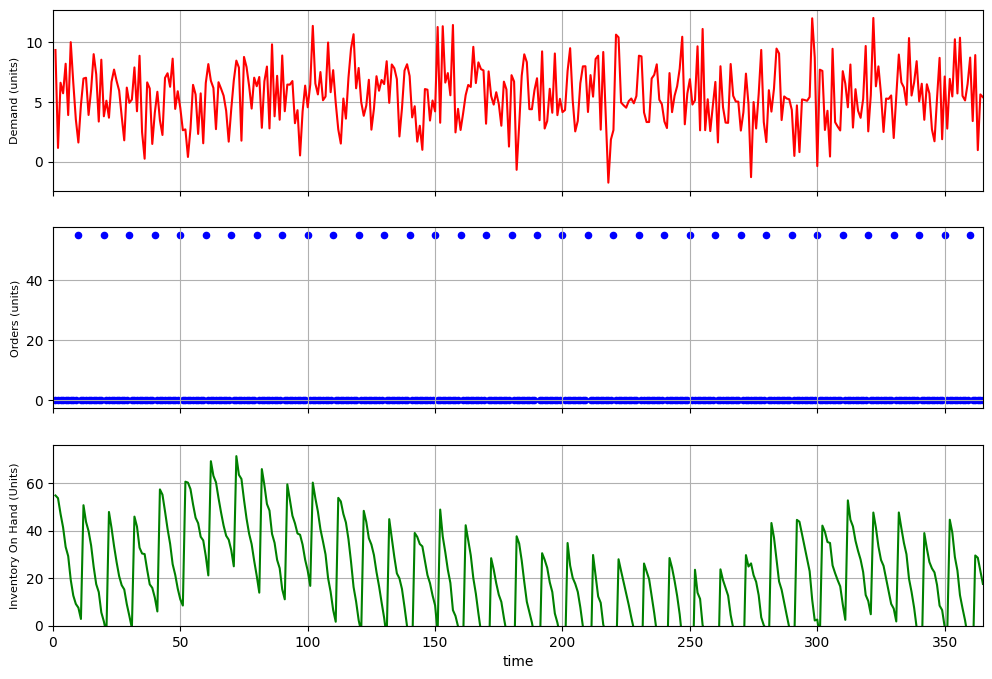

In [21]:
# Total Demand (yearly)
D4 = 2000
# Lead Time (days)
LD4 = 2
# Ordering Quantity (units)
Q4 = D_day * (T)
# Initial Inventory on Hand (units)
initial_ioh4=Q4

# Import Parameters
params4 = InventoryParams(
    D=D4,
    T_total=T_total,
    LD=LD4,
    T=T,
    Q=Q4,
    initial_ioh=initial_ioh4,
    sigma = 2.5
)

# Create simulation
simulate_4 = InventorySimulation(params4)
sim4 = simulate_4.simulation_3()

# Create plot to visualize inventory levels over time
fig, axes = plt.subplots(3, 1, figsize= (12,8), sharex=True)

# Plot the demand
sim4.plot(x='time', y = 'demand', ax = axes[0], color='red', legend=False, grid = True)
axes[0].set_ylabel('Demand (units)', fontsize = 8)

# Orders
sim4.plot.scatter(x='time', y = 'order', ax = axes[1], color='blue', legend=False, grid = True)
axes[1].set_ylabel('Orders (units)', fontsize = 8)

# Inventory on Hand
sim4.plot(x='time', y = 'ioh', ax = axes[2], color='green', legend=False, grid = True)
axes[2].set_ylabel('Inventory On Hand (Units)', fontsize = 8)

# Format x axis
axes[2].set_xlim(0, T_total)
axes[2].set_ylim(0)